In [1]:
from random import random

import numpy as np
import os
import torch

import utils
from utils import *
from unet import ImCondModel, UNetModel_imcond_wrapper
from topodataset import TopoDataSet
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from skimage.filters import threshold_otsu, gaussian, sobel
from skimage.morphology import remove_small_holes
from scipy.ndimage import distance_transform_edt

In [2]:
torch.cuda.is_available()

True

In [3]:
weight_path = 'model_weights/icfm_topo_weights_step_345000.pt'

In [4]:
# load the data:
# DATASETS/DATALOADER
bs=4
num_workers=0
downsampling_factor=1
limit_num_data=np.inf
crop_size=300
use_cfg=True
use_ddc=True
threshold_input=True


dataset = TopoDataSet(
    dir='data/',
    downsampling_factor=downsampling_factor,
    limit_num_data=limit_num_data,
    crop_size=crop_size,
    threshold_input=threshold_input,
    get_only_last_10p=True
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=bs,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 69/69 [00:00<?, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 70/70 [00:00<00:00, 72583.75it/s]
0it [00:00, ?it/s]
100%|██████████| 85/85 [00:00<00:00, 82872.12it/s]
0it [00:00, ?it/s]
100%|██████████| 72/72 [00:00<00:00, 362968.62it/s]
0it [00:00, ?it/s]
100%|██████████| 86/86 [00:00<?, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 64/64 [00:00<00:00, 60066.11it/s]
0it [00:00, ?it/s]
100%|██████████| 54/54 [00:00<00:00, 102531.65it/s]
0it [00:00, ?it/s]
100%|██████████| 43/43 [00:00<00:00, 105780.10it/s]
0it [00:00, ?it/s]
100%|██████████| 62/62 [00:00<00:00, 73026.35it/s]
0it [00:00, ?it/s]
100%|██████████| 61/61 [00:00<00:00, 186481.45it/s]
0it [00:00, ?it/s]
100%|██████████| 70/70 [00:00<?, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 72/72 [00:00<00:00, 295489.13it/s]
0it [00:00, ?it/s]
100%|██████████| 66/66 [00:00<00:00, 163898.20it/s]

dataset contains 874 images


In [5]:
# get some images:
all_imgs = []
all_bgs = []
for i, (img, bg) in tqdm(enumerate(dataloader), total=len(dataloader)):
    all_imgs.append(img)
    all_bgs.append(bg)


  0%|          | 0/218 [00:00<?, ?it/s]

D:\topochip-flow-matching\Topochip-flow-matching\utils.py:259: RuntimeWarning: All-NaN slice encountered
  assert (np.nanmin(np.where(arr > (0+(1e-6)), arr_norm, np.nan), axis=(0,1)) >= (0-1e-6)).all() or (arr==0).all((0,1)).any(), 'normalization did not give expected results: lowest < 0'


In [6]:
all_imgs = torch.cat(all_imgs, dim=0)
all_bgs = torch.cat(all_bgs, dim=0)
all_imgs *= 0.5
all_imgs += 0.5

In [7]:
print(all_imgs.shape)

torch.Size([872, 3, 300, 300])


In [8]:


# Load the model
h = w = 300
num_channel = 32
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

inject_imcond = True

if not inject_imcond:
    model = ImCondModel(
        dim=(3, h, w),  # note: in local test run we had this worng (dim was at (..., 32, 32). which effectively means we were applying attention after only one time downsampling (att. resolutions was 16)
        num_res_blocks=2,
        num_channels=num_channel,
        channel_mult=[1, 1, 2, 2, 2],
        num_heads=4,
        num_head_channels=-1,
        attention_ds=(2**5,),
        dropout=0.1,
    ).to(
        device
    )  # new dropout + bs of 128
else:
    num_im_cond_channels = 1
    if use_cfg:
        num_im_cond_channels  += 1
    if use_ddc:
        num_im_cond_channels += 3  # 3 as the cell staining images have 3 channels
    model = UNetModel_imcond_wrapper(
        dim=(3, h, w),
        num_res_blocks=2,
        num_channels=num_channel,
        channel_mult=[1, 1, 2, 2, 2],
        num_heads=4,
        num_head_channels=-1,
        attention_ds=(2**5,),
        dropout=0.1,
        num_cond_im_channels=num_im_cond_channels,
    ).to(device)
    


cuda
using model with image conditioning injection in unet!


D:\topochip-flow-matching\Topochip-flow-matching\venv\Lib\site-packages\torch\nn\init.py:453: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [9]:
checkpoint = torch.load(weight_path, map_location=torch.device(device))

C:\Users\s161975\AppData\Local\Temp\ipykernel_2208\3910598975.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path, map_location=torch.dev

In [10]:
# checkpoint.keys()

In [11]:
key = 'ema_model'  # or 'net_model'
# key = 'net_model'
model.load_state_dict(checkpoint[key])

<All keys matched successfully>

In [12]:
model.to(device)

UNetModel_imcond_wrapper(
  (time_embed): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (input_blocks): ModuleList(
    (0): TimestepEmbedSequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1-2): 2 x TimestepEmbedSequential(
      (0): ResBlock(
        (in_layers): Sequential(
          (0): GroupNorm32(32, 32, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (h_upd): Identity()
        (x_upd): Identity()
        (emb_layers): Sequential(
          (0): SiLU()
          (1): Linear(in_features=128, out_features=32, bias=True)
        )
        (imcond_emb_layers): Sequential(
          (0): SiLU()
          (1): LazyConv2d(0, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (out_layers): Sequential(
          (

# Loading finished -> move to experiments

In [29]:
import datetime

today = datetime.datetime.today()
def find_center(img, channel=-1):
    # find the max intensity pixerl for the specified channel to determine the center
    i_flat = np.argmax(img[...,channel])
    i = np.unravel_index(i_flat, shape=img[...,channel].shape)
    return i

def zoom_image(img, center, pixels):
    assert len(img.shape) == 3
    low, high = center[0] - pixels//2, center[0] + pixels//2
    low = min(max(0, low), img.shape[0] - pixels)
    high = max(min(img.shape[0], high), pixels)
    left, right = center[1] - pixels//2, center[1] + pixels//2
    left = min(max(0, left), img.shape[0] - pixels)
    right = max(min(img.shape[0], right), pixels)
    img = img[low:high, left:right]
    return img, (low, high, left, right)

7

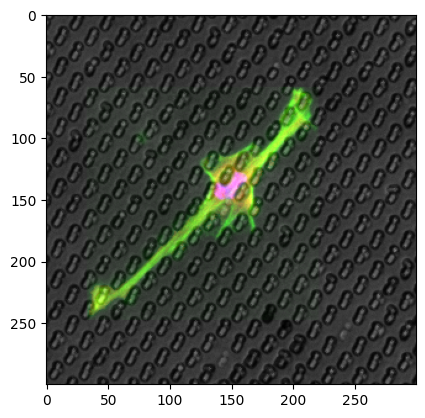

In [45]:
# choose image and observed channel:
idx = 0  # idxs 1, 22
observed_channel = 2 # 0 -- yap, 1 -- actin, 2 -- dapi


channel_names = ['YAP', 'Actin', 'Dapi']
img_and_bg_real = torch.cat([all_bgs[idx], all_imgs[idx]], dim=0)
to_plot = plot_topo_cells(img_and_bg_real.cpu().permute(1, 2, 0).numpy(), bg_norm=0.5) / 255.
plt.imshow(to_plot)
plt.show()

In [46]:
# generate images conditioned on the observed stain and background of the first image

k = 3
bs = 3

imgs_gen = []
imgs_real = []


for i in tqdm(range(np.ceil(k/bs).astype(int))):
    bg = all_bgs[idx][None, ...].to(device)
    bg = utils.prepare_cfg_conditioning(bg, 0) if use_cfg else bg
    some_bgs = bg[None, ...].repeat(bs,1, 1,1,1).to(device)
    mask = torch.zeros(bs,1, 3, h, w).to(device)
    mask[:,:, observed_channel] = 1  # observed channel
    img = all_imgs[idx]
    thresh = threshold_otsu(img.cpu().numpy())
    img_masked = img #* (img > thresh).float()
    x1 = img_masked.repeat(bs,1,1,1).to(device)*2-1
    imgs_this_gen = generate_samples_topo(model, False, None, 0, 'test', some_bgs, num_int_steps=100, obs_mask=mask,
                                          x1=x1)
    imgs_gen.append(imgs_this_gen)
    img_and_bg_real = torch.cat([all_bgs[idx][None, ...], all_imgs[idx][None, ...]], dim=1).repeat(bs,1,1,1)
    imgs_real.append(img_and_bg_real)

imgs_gen = torch.cat(imgs_gen, dim=0)
imgs_real = torch.cat(imgs_real, dim=0)



  0%|          | 0/1 [00:00<?, ?it/s]

Your vector field does not have `nn.Parameters` to optimize.


In [47]:
# # verify that the observed channel remains the same in generated images
# gen = imgs_gen[1,observed_channel+ 1]
# plt.imshow(gen)
# plt.show()

# gen = imgs_gen[2,observed_channel + 1]
# plt.imshow(gen)
# plt.show()

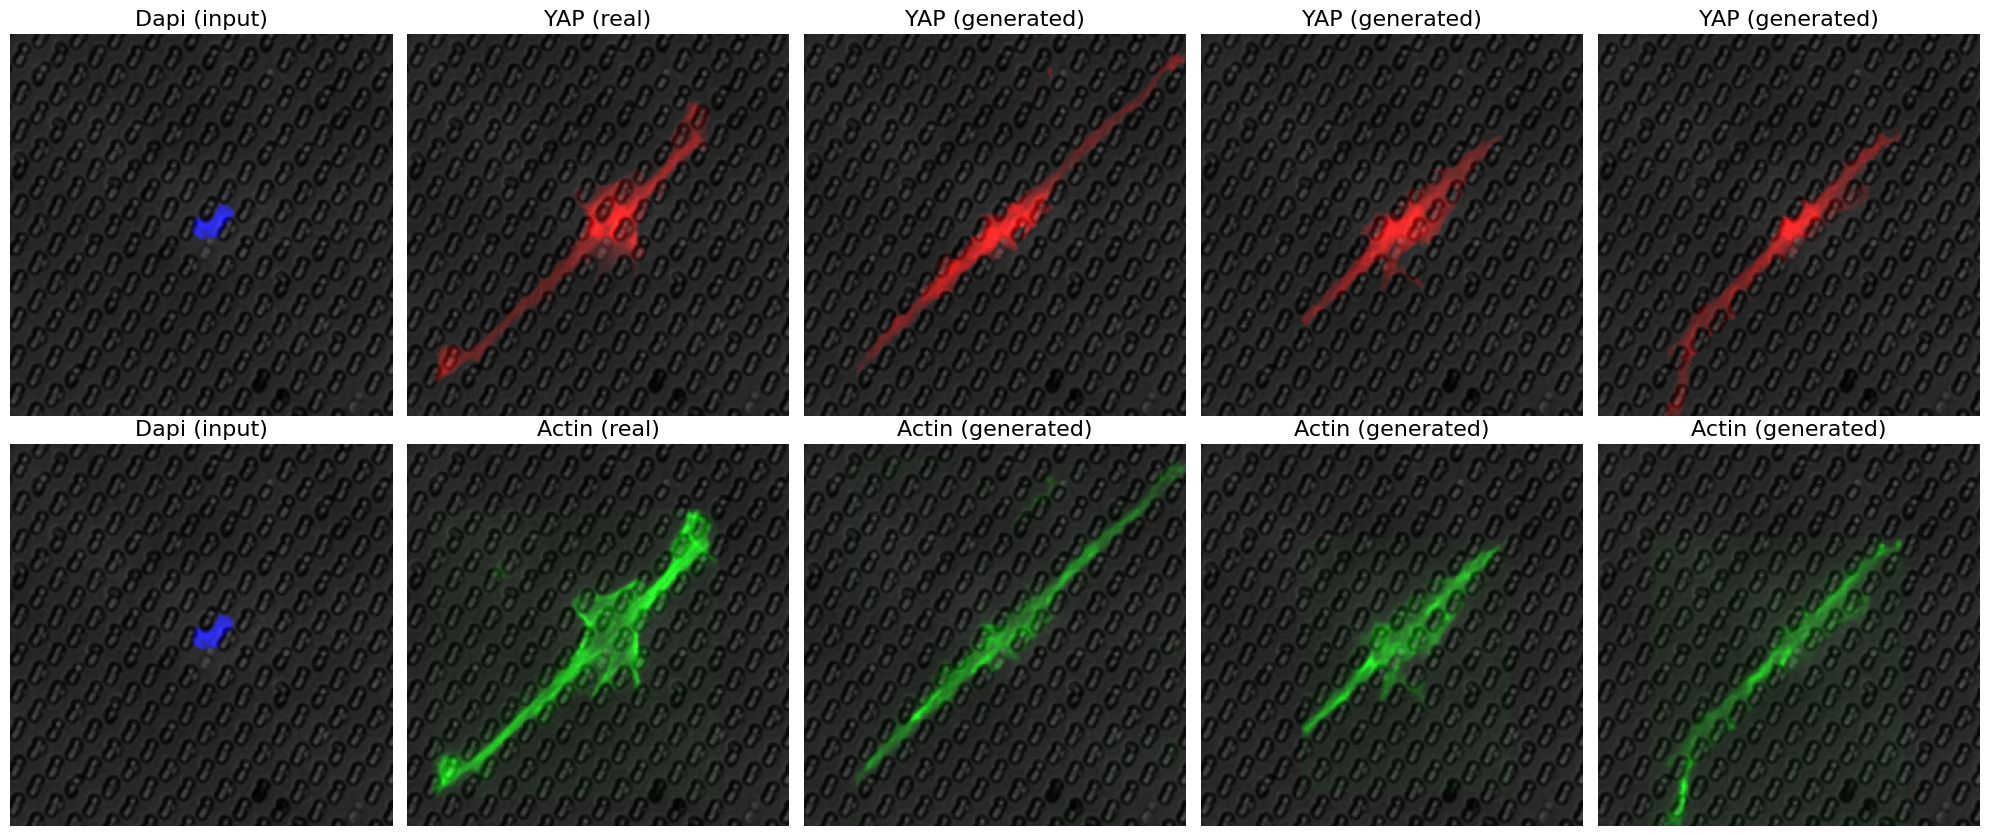

In [48]:
# plotting parameters:
channels_to_plot_separate = sorted(list(set([0,1,2]) - set([observed_channel])))  # 0 - yap, 1 - actin, 2 - dapi
k_to_plot = 5
pixels = 250
fig, axs = plt.subplots(2, k_to_plot, figsize=(k_to_plot*4,8.5))

spath = 'qualitative_images_partial_obs/'
if not os.path.exists(spath):
    os.makedirs(spath)
    



# now plot the fake completions:
# first plot real image's input channel on the left
# plot fake completions:
for i, channel_to_plot_separate in enumerate(channels_to_plot_separate):
    for j in range(k_to_plot):
        img_and_bg = imgs_real[0, :] if j <=1 else imgs_gen[j-2, :]
        img_and_bg_reshaped = img_and_bg.cpu().permute(1, 2, 0).numpy()
        mask = np.zeros_like(img_and_bg_reshaped)
        ch = observed_channel if j==0 else channel_to_plot_separate
        mask[..., ch+1] = 1   # ch+1 because we still have the bg here
        mask[..., 0] = 1
        im_to_plot =  plot_topo_cells(img_and_bg_reshaped * mask, bg_norm=0.35) / 255.
            
        center = find_center(imgs_real[0, :].cpu().permute(1, 2, 0).numpy()[..., 1:], channel=-1)  # always base on dapi center of real so that loc stays consistent
        im_to_plot, _ = zoom_image(im_to_plot, center, pixels)
        
        axs[i,j].imshow(im_to_plot)
        axs[i,j].axis('off')
        if j == 0:
            lab = f'{channel_names[observed_channel]} (input)'
        elif j == 1:
            lab = f'{channel_names[channel_to_plot_separate]} (real)'
        else:
            lab = f'{channel_names[channel_to_plot_separate]} (generated)'
        
        axs[i,j].set_title(lab, fontsize=16)



    
plt.tight_layout(w_pad=1.08, h_pad=1.08)
plt.savefig(spath + f'{today.month}_{today.day}_qualitative_obs__{idx}_obs_{channel_names[observed_channel]}.png', dpi=100, transparent=True)
plt.show()

## modify cortical actin in the cell and check the YAP response (not used for V! manuscript)

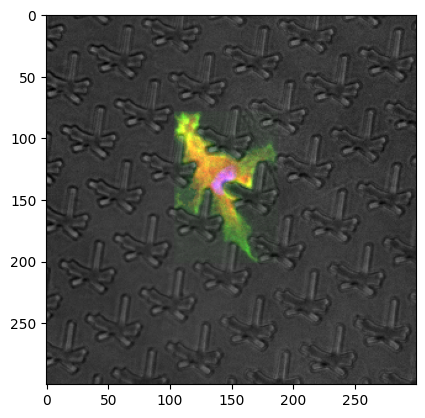

In [181]:
# choose image and observed channel:
idx = 14
observed_channel = 1 # 0 -- yap, 1 -- actin, 2 -- dapi


channel_names = ['yap', 'actin', 'dapi']
img_and_bg_real = torch.cat([all_bgs[idx], all_imgs[idx]], dim=0)
to_plot = plot_topo_cells(img_and_bg_real.cpu().permute(1, 2, 0).numpy(), bg_norm=0.5) / 255.
plt.imshow(to_plot)
plt.show()

In [ ]:
def segment_cell(actin_img):
    # find the segmentation of the cell:
    actin_blurred = gaussian(actin_img, sigma=5)
    actin_mask = actin_img >= threshold_otsu(actin_blurred)
    actin_mask = remove_small_holes(actin_mask.numpy(), area_threshold=2500)
    return actin_mask

def find_cortical_mask(actin_img, cortical_width=3):
    actin_mask = segment_cell(actin_img)
    dist_to_bg = distance_transform_edt(actin_mask)
    cortical_and_outside_mask = dist_to_bg <= cortical_width
    return cortical_and_outside_mask

def reduce_cortical_actin(img_no_bg, cortical_and_outside_mask, dim_factor=0.5):
    # actin channel has index 2. img and bg is channels-first
    assert img_no_bg.shape[0] == 3 and len(img_no_bg.shape) == 3
    img_no_bg = np.array(img_no_bg)
    dimmed_actin = img_no_bg[1] * dim_factor
    img_no_bg[1] = cortical_and_outside_mask * dimmed_actin + (1-cortical_and_outside_mask) * img_no_bg[1]
    return img_no_bg

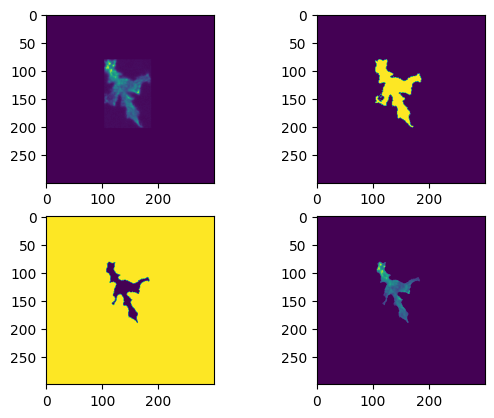

In [183]:
# plot:
# original image, actin mask,
# everything that is cortical our outside the cell mask, reduced cortical actin intensities

fig, axs = plt.subplots(2,2)

axs[0,0].imshow(img_and_bg_real[2])

axs[0,1].imshow(segment_cell(img_and_bg_real[2]))
cortical_and_outside_mask = find_cortical_mask(img_and_bg_real[2])
axs[1,0].imshow(cortical_and_outside_mask)
img_and_bg_real_red = reduce_cortical_actin(img_and_bg_real[1:], cortical_and_outside_mask, dim_factor=0.0)
axs[1,1].imshow(img_and_bg_real_red[1])
plt.show()

In [184]:
# generate completions based on obsvered actin stains:

# generate images conditioned on the observed stain and background of the first image

dim_factors = [0.0, 0.25, 0.5, 0.75, 1.0]
bs = 5

assert len(dim_factors) // bs == len(dim_factors) / bs, 'bs should fit integer amounts in dim_factors len'
imgs_gen = []
imgs_real = []

k= len(dim_factors)

for i in tqdm(range(np.ceil(k/bs).astype(int))):
    bg = all_bgs[idx][None, ...].to(device)
    bg = utils.prepare_cfg_conditioning(bg, 0) if use_cfg else bg
    # repeat bgs along batch dim:
    some_bgs = bg[None, ...].repeat(bs,1, 1,1,1).to(device)

    # handle stain and mask for model generation:
    mask = torch.zeros(bs,1, 3, h, w).to(device)
    mask[:,:, observed_channel] = 1  # observed channel
    img = all_imgs[idx]
    cortical_and_outside_mask = find_cortical_mask(img[1])
    # plt.imshow(img[1])
    # plt.show()
    # plt.imshow(cortical_and_outside_mask)
    # plt.show()
    x1 = img.repeat(bs,1,1,1)
    for img_idx in range(x1.shape[0]):
        # print(x1[img_idx].shape)
        reduced_actin_img = reduce_cortical_actin(x1[img_idx], cortical_and_outside_mask, dim_factors[i*bs+img_idx])
        x1[img_idx] = torch.from_numpy(reduced_actin_img)
        # plt.imshow(reduced_actin_img[1])
        # raise ValueError()
    x1 = x1.to(device)*2-1
    imgs_this_gen = generate_samples_topo(model, False, None, 0, 'test', some_bgs, num_int_steps=100, obs_mask=mask,
                                          x1=x1)
    imgs_gen.append(imgs_this_gen)
    img_and_bg_real = torch.cat([all_bgs[idx][None, ...], all_imgs[idx][None, ...]], dim=1).repeat(bs,1,1,1)
    imgs_real.append(img_and_bg_real)

imgs_gen = torch.cat(imgs_gen, dim=0)
imgs_real = torch.cat(imgs_real, dim=0)





  0%|          | 0/1 [00:00<?, ?it/s]

Your vector field does not have `nn.Parameters` to optimize.


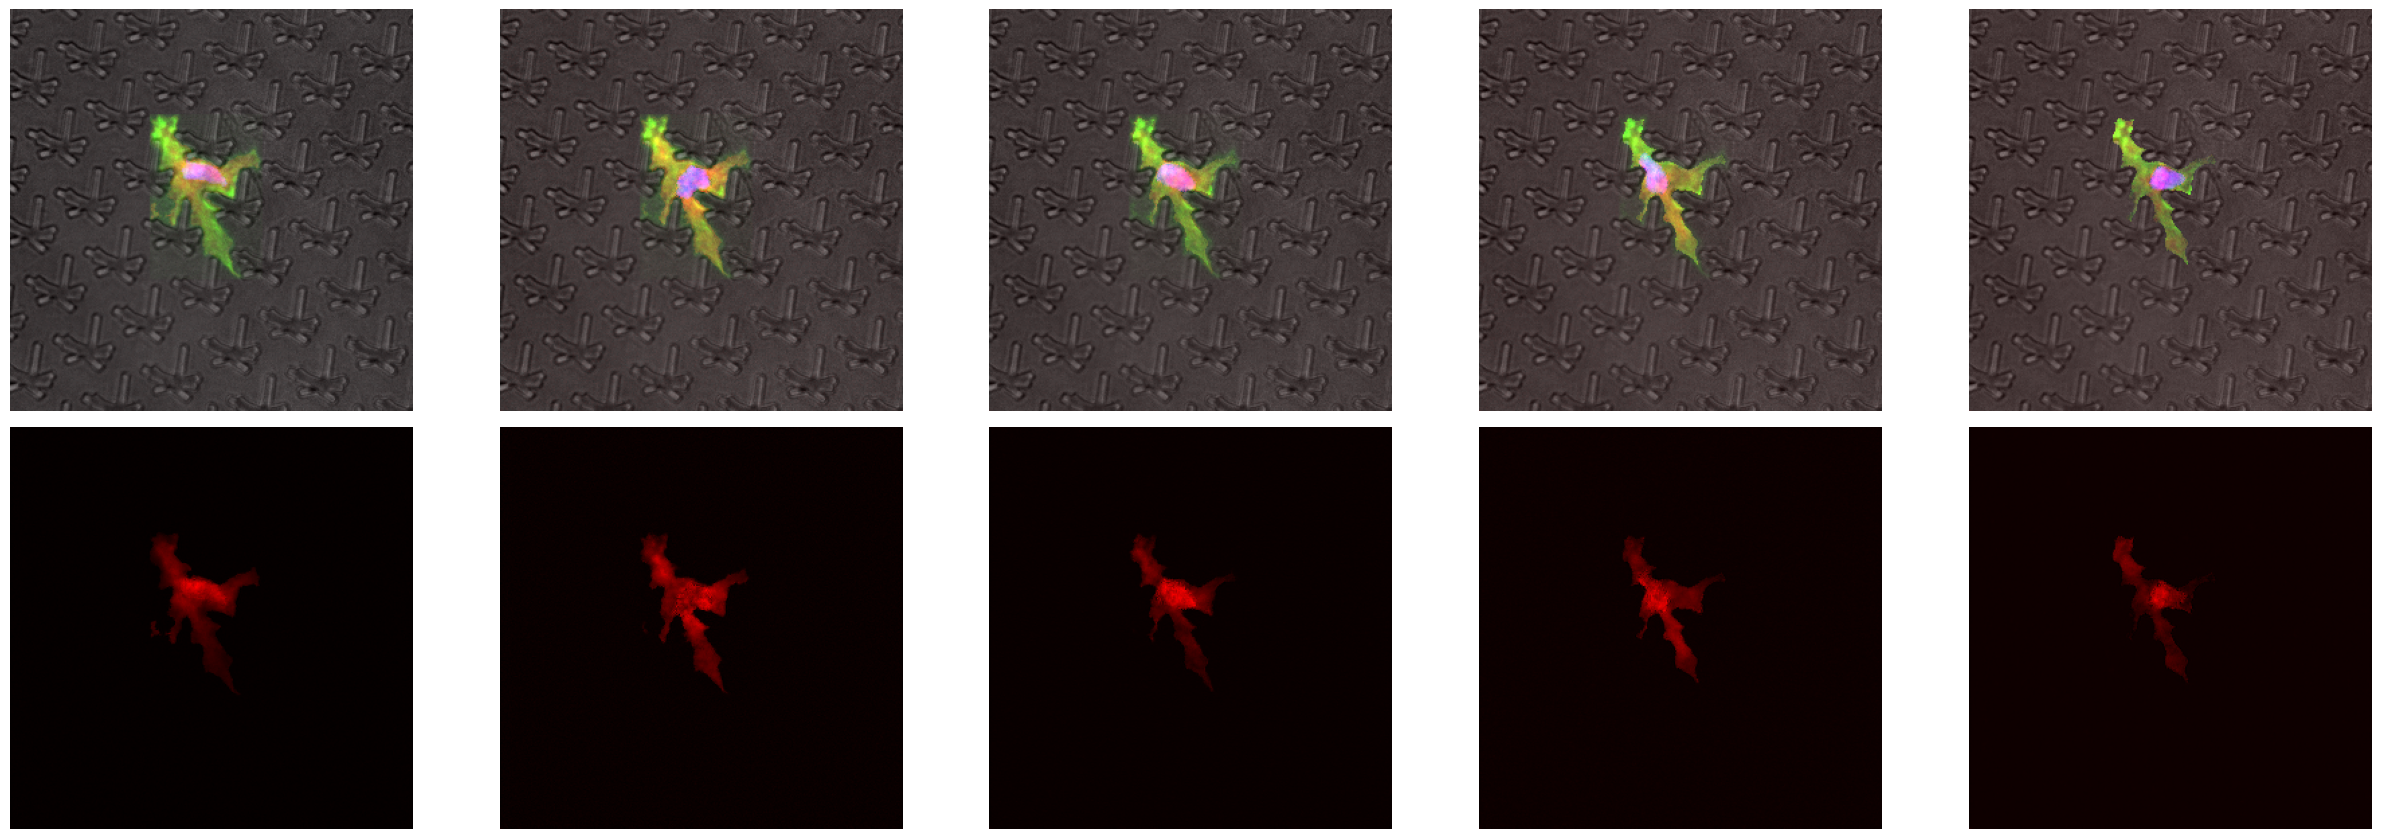

In [185]:
# plotting parameters:
channel_to_plot_separate = 0  # 0 - yap, 1 - actin, 2 - dapi
k_to_plot = 5
fig, axs = plt.subplots(2, k_to_plot, figsize=(k_to_plot*5,8.5))

spath = 'qualitative_images_partial_obs/'
if not os.path.exists(spath):
    os.makedirs(spath)
    
js = list(reversed(range(k_to_plot)))



# now plot the fake completions:
for i in range(2):
    
    # plot fake completions:
    for j_temp in range(k_to_plot):
        a  = axs[i, j_temp]
        j = js[j_temp]
        img_and_bg = imgs_gen[j, :]
            # bg = imgs[j, 0]
        # plot superimposed cell on bg:
        if i == 0: # plot complete image
            im_to_plot =  plot_topo_cells(img_and_bg.cpu().permute(1, 2, 0).numpy(), bg_norm=0.5) / 255.
        if i == 1:
            im_to_plot =  plot_topo_cells(img_and_bg.cpu().permute(1, 2, 0).numpy(), bg_norm=0.0) / 255.
            mask = np.zeros_like(im_to_plot)
            mask[..., channel_to_plot_separate] = 1
            im_to_plot = im_to_plot * mask
        # im_to_plot[...,0] = 0
        a.imshow(im_to_plot)
        # a.imshow(img.permute(1, 2, 0).cpu().detach().numpy())
        a.axis('off')
    
    
plt.tight_layout(w_pad=1.08, h_pad=1.08)
plt.savefig(spath + f'qualitative_obs_cortical_{idx}.png', dpi=100, transparent=True)
plt.show()

# old trash below:

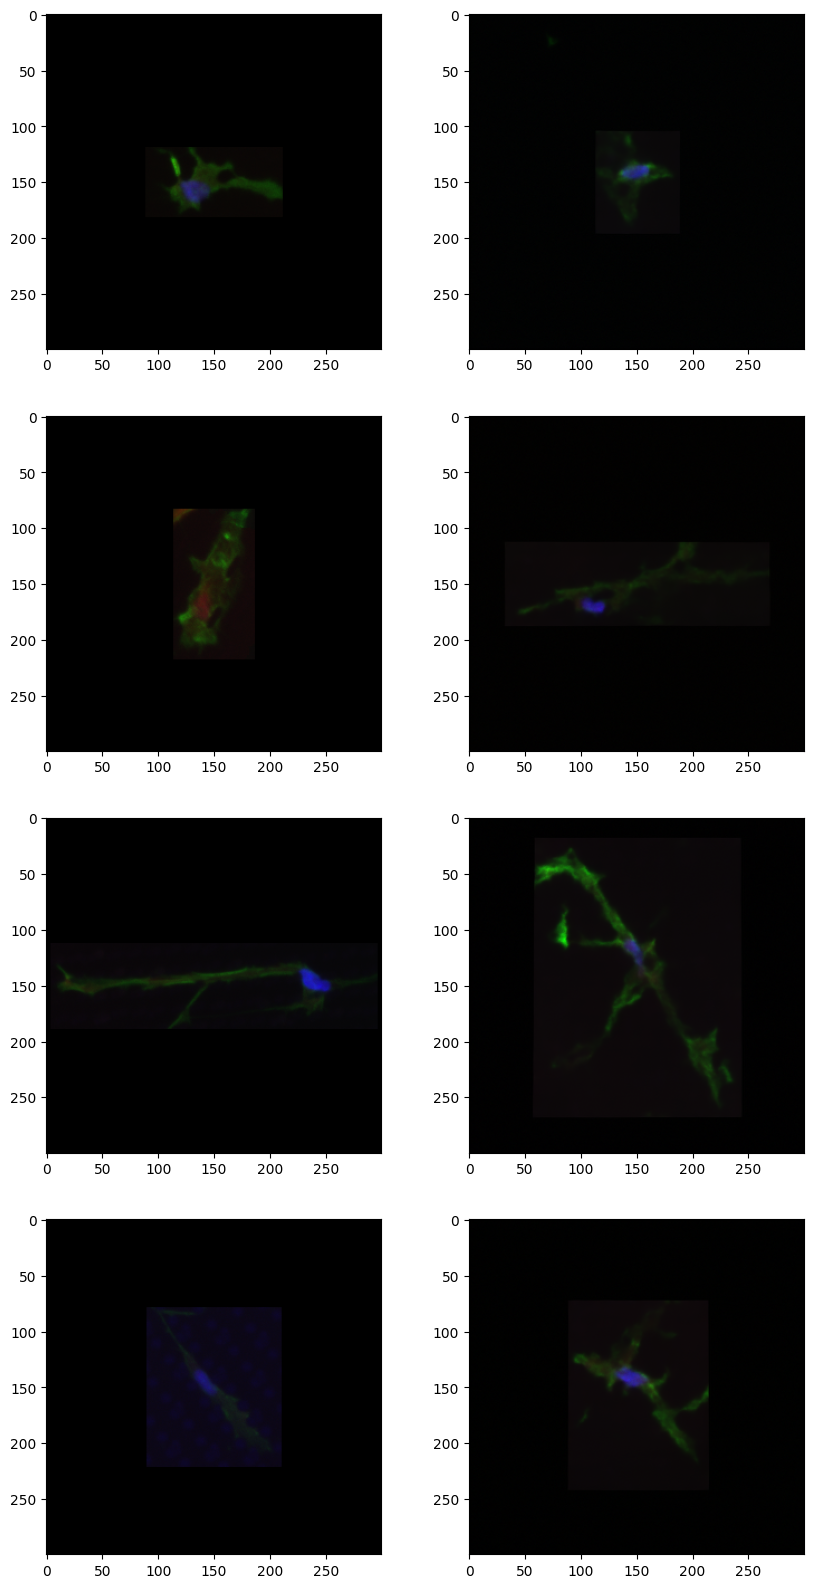

In [17]:
fig, axs = plt.subplots(bs, 2, figsize=(10,5*bs))
real_locs = []
for i in range(bs):
    u = np.random.uniform()
    if u < 0.5:
        real_idx=0
    else:
        real_idx=1
    axs[i, real_idx].imshow(all_imgs[i].permute(1,2,0).cpu().numpy())
    axs[i, 1-real_idx].imshow(imgs[i, 1:].permute(1,2,0).cpu().numpy())
    real_locs.append(real_idx)
plt.show()


In [7]:
bs=4
num_workers=0
downsampling_factor=1
limit_num_data=np.inf
crop_size=300
dataset = TopoDataSet(
    dir='data/',
    downsampling_factor=downsampling_factor,
    limit_num_data=limit_num_data,
    crop_size=crop_size,
    return_filename=True
)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=bs,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

dataset contains 5664 images


In [19]:
num_samples_to_make = 4
stain_names = ['background', 'YAP', 'Actin', 'DAPI']
spath = 'generated_images_tiff/'

for counter, (img, bg, filenames) in tqdm(enumerate(dataloader), total=int(np.ceil(num_samples_to_make / bs))):
    if counter * bs >= num_samples_to_make:
        break
    bg = bg[None, ...].to(device)  # add leading dim for the generation function
    bg_and_img = generate_samples_topo(model, False, None, 0, 'test', bg)
    for b in range(bg_and_img.shape[0]):
        filename = filenames[b]
        for c in range(bg_and_img.shape[1]):
            img_c = bg_and_img[b, c]  # shape (h,w)
            img_c = img_c.cpu().detach().numpy()
            img_c = (img_c * 255).astype(np.uint8)
            img_c = Image.fromarray(img_c)
            chip_folder = filename[filename.find('Chip'):filename.find('Chip')+11]
            obj_num = filename[filename.find('NucleiNr')+8:filename.find('NucleiNr')+12]
            fname_save = f'obj{obj_num}_stain{stain_names[c]}_fake.tiff'
            if not os.path.exists(os.path.join(spath, chip_folder +'_fake')):
                os.makedirs(os.path.join(spath, chip_folder +'_fake'))
            img_c.save(os.path.join(spath, chip_folder +'_fake', fname_save))


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [14]:
img_c.shape

torch.Size([300, 300])

In [32]:
# trajs = generate_samples_topo(model, False, None, 0, 'test', some_bgs, return_whole_traj=True)  # shape (100, bs, c, h, w)

In [41]:
# trajs = trajs / 2 + 0.5

MovieWriter imagemagick unavailable; using Pillow instead.


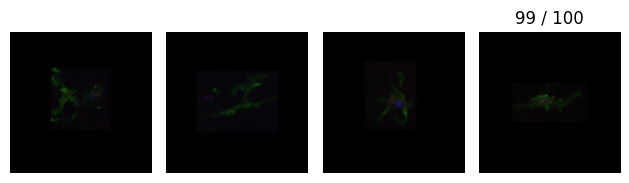

MovieWriter imagemagick unavailable; using Pillow instead.


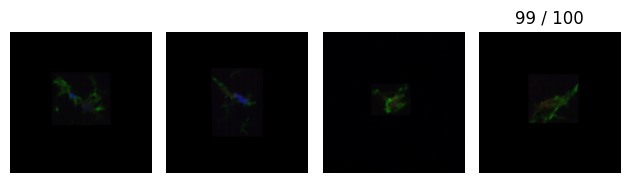

MovieWriter imagemagick unavailable; using Pillow instead.


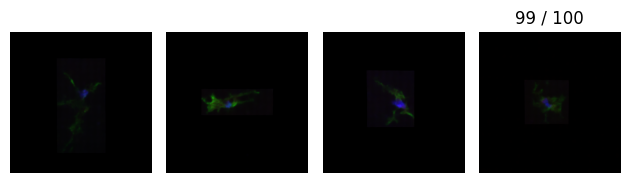

MovieWriter imagemagick unavailable; using Pillow instead.


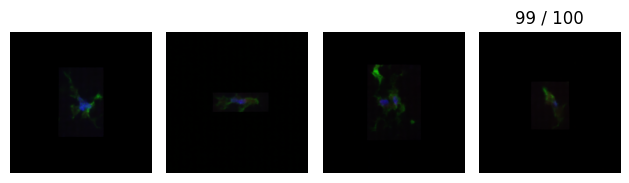

MovieWriter imagemagick unavailable; using Pillow instead.


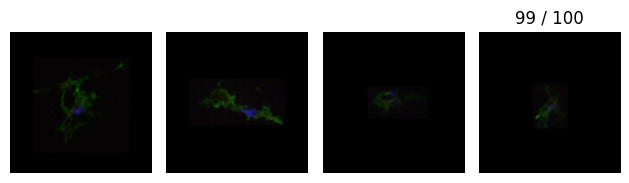

In [59]:
# make and save a gif animation of the trajectory using matplotlib funcanimation:
import matplotlib.animation as animation
from matplotlib import rc
import os



savedir = 'gifs/'
if not os.path.exists(savedir):
    os.makedirs(savedir)

num_reps = 5

for rep in range(num_reps):
    trajs = generate_samples_topo(model, False, None, 0, 'test', some_bgs, return_whole_traj=True)  # shape (100, bs, c, h, w)
    trajs = trajs / 2 + 0.5
    
    fig, ax = plt.subplots(ncols=4)
    fig.set_tight_layout(True)
    
    ims = []
    for j in range(4):
        im_j = ax[j].imshow(trajs[0, j].permute(1, 2, 0).cpu().detach().numpy())
        ax[j].axis('off')
        ims.append(im_j)
    
    
    def update(i):
        # set the title of the figure to the iteration number:
        plt.title(f'{i} / {trajs.shape[0]}')
        for j in range(4):
            ims[j].set_array(trajs[i, j].permute(1, 2, 0).cpu().detach().numpy())
        return ims
    
    ani = animation.FuncAnimation(fig, update, frames=100, blit=True)
    ani.save(savedir + f'traj_{rep}.gif', writer='imagemagick', fps=10)
    plt.show()


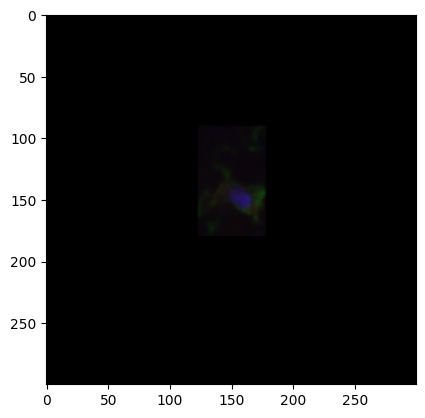

In [40]:
plt.imshow(trajs[-1,0].permute(1,2,0) / 2 + 0.5)
plt.show()

In [13]:
imgs.shape  # (bs, c, h, w)

torch.Size([4, 4, 300, 300])

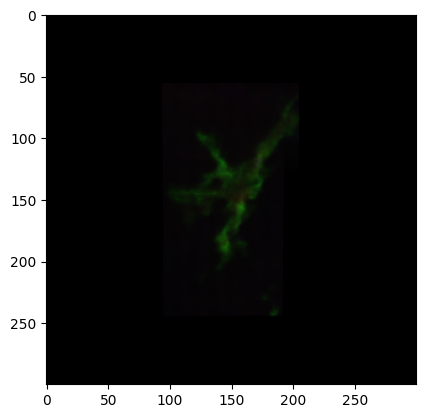

In [14]:
plt.figure()
plt.imshow(imgs[0, 1:].permute(1, 2, 0).cpu().detach().numpy())
plt.show()

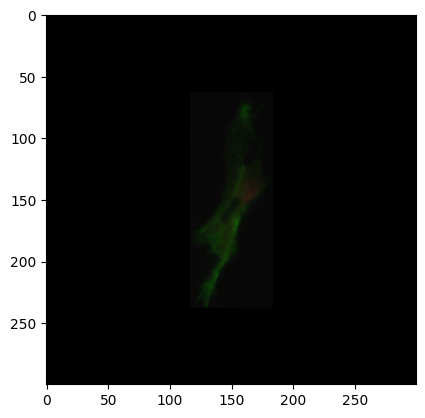

In [15]:
plt.figure()
plt.imshow(all_imgs[0].permute(1, 2, 0).cpu().detach().numpy())
plt.show()

In [16]:
all_imgs.max()

tensor(1.)

In [17]:
imgs[:,1:].min()

tensor(0., device='cuda:0')

In [18]:
# test = imgs[0, 1:].permute(1, 2, 0).cpu().detach().numpy()
# plt.hist(test.reshape(-1))
# plt.show()

In [24]:
# now do similarity search over the training set to find the k most similar images as the generated ones:

@torch.no_grad()
def similarity_search(generated_imgs, training_imgs, k=5, img_feat_extractor=lambda x: x, bs=32, use_cos_sim=False):
    # imgs: (bs, c, h, w)
    # all_imgs: (n, c, h, w)
    # k: int
    # returns: (bs, k, c, h, w)
    generated_imgs_preproc = []
    training_imgs_preproc = []
    print('starting preprocessing')
    for i in tqdm(range(0, generated_imgs.shape[0], bs)):
        generated_imgs_preproc.append(img_feat_extractor(generated_imgs[i:i+bs]).cpu())
    generated_imgs = torch.cat(generated_imgs_preproc, dim=0)
    for i in tqdm(range(0, training_imgs.shape[0], bs)):
        training_imgs_preproc.append(img_feat_extractor(training_imgs[i:i+bs]).cpu())
    training_imgs = torch.cat(training_imgs_preproc, dim=0)
    print(generated_imgs.shape)
    bs = generated_imgs.shape[0]
    n = training_imgs.shape[0]
    generated_imgs = generated_imgs.view(bs, -1)
    training_imgs = training_imgs.view(n, -1)
    if use_cos_sim:
        cos_sim = torch.nn.CosineSimilarity(dim=-1)
        sims = cos_sim(generated_imgs[:, None, :], training_imgs[None, :, :])
        dists = -sims
    else:
        dists = torch.cdist(generated_imgs, training_imgs)
    top_k = torch.topk(dists, k, dim=1, largest=False)
    return top_k.indices



In [25]:
k=3
top_k_idx = similarity_search(imgs[:, 1:].cpu(), all_imgs.cpu(), k=k, use_cos_sim=True)

starting preprocessing


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

torch.Size([4, 3, 300, 300])


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 24468480000 bytes.

In [21]:
# top_k_idx

NameError: name 'top_k_idx' is not defined

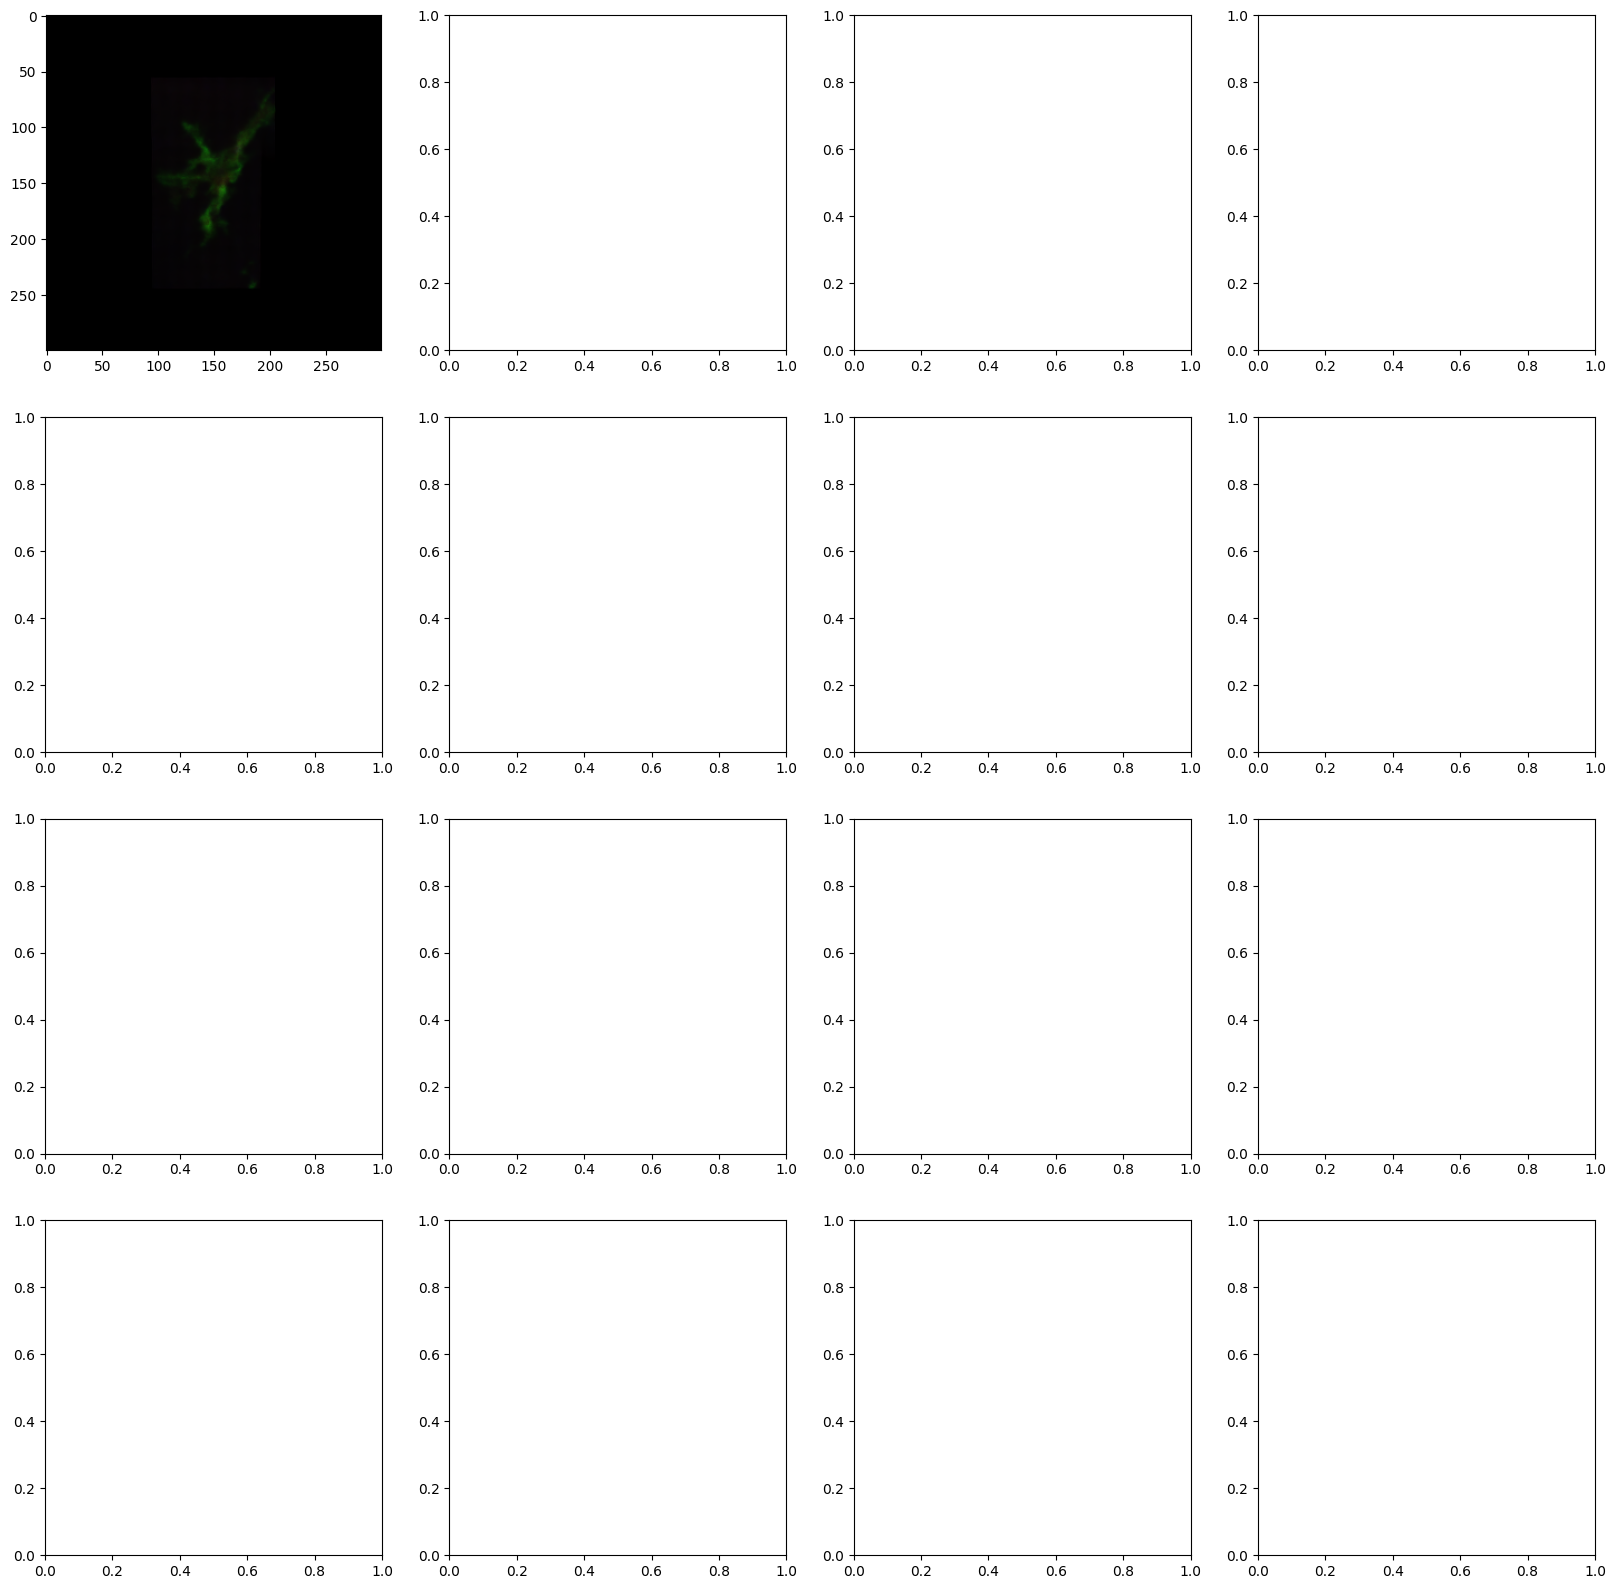

In [22]:
# plot the top_k most similar images:
fig, axs = plt.subplots(nrows=k+1, ncols=bs, figsize=(20,20))
for i in range(bs):
    axs[0, i].imshow(imgs[i, 1:].permute(1, 2, 0).cpu().detach().numpy()) # the first row is the generated images
    for j in range(k):
        axs[j+1, i].imshow(all_imgs[top_k_idx[i, j]].permute(1, 2, 0).cpu().detach().numpy())
        
plt.show()

In [49]:
# extract features using a pretrained model:
# device = 'cpu'
# first get the model":
import torchvision.models as models
model = models.resnet18(pretrained=True)
layer_feats = -8
feature_extractor = torch.nn.Sequential(*list(model.children())[:layer_feats]).to(device)

In [50]:
torch.cuda.empty_cache()

In [ ]:
top_k_idx_feat_extr = similarity_search(imgs[:, 1:].to(device), all_imgs.to(device), k=k,
                                        img_feat_extractor=lambda x: feature_extractor(x), bs=16, use_cos_sim=True)


starting preprocessing


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/354 [00:00<?, ?it/s]

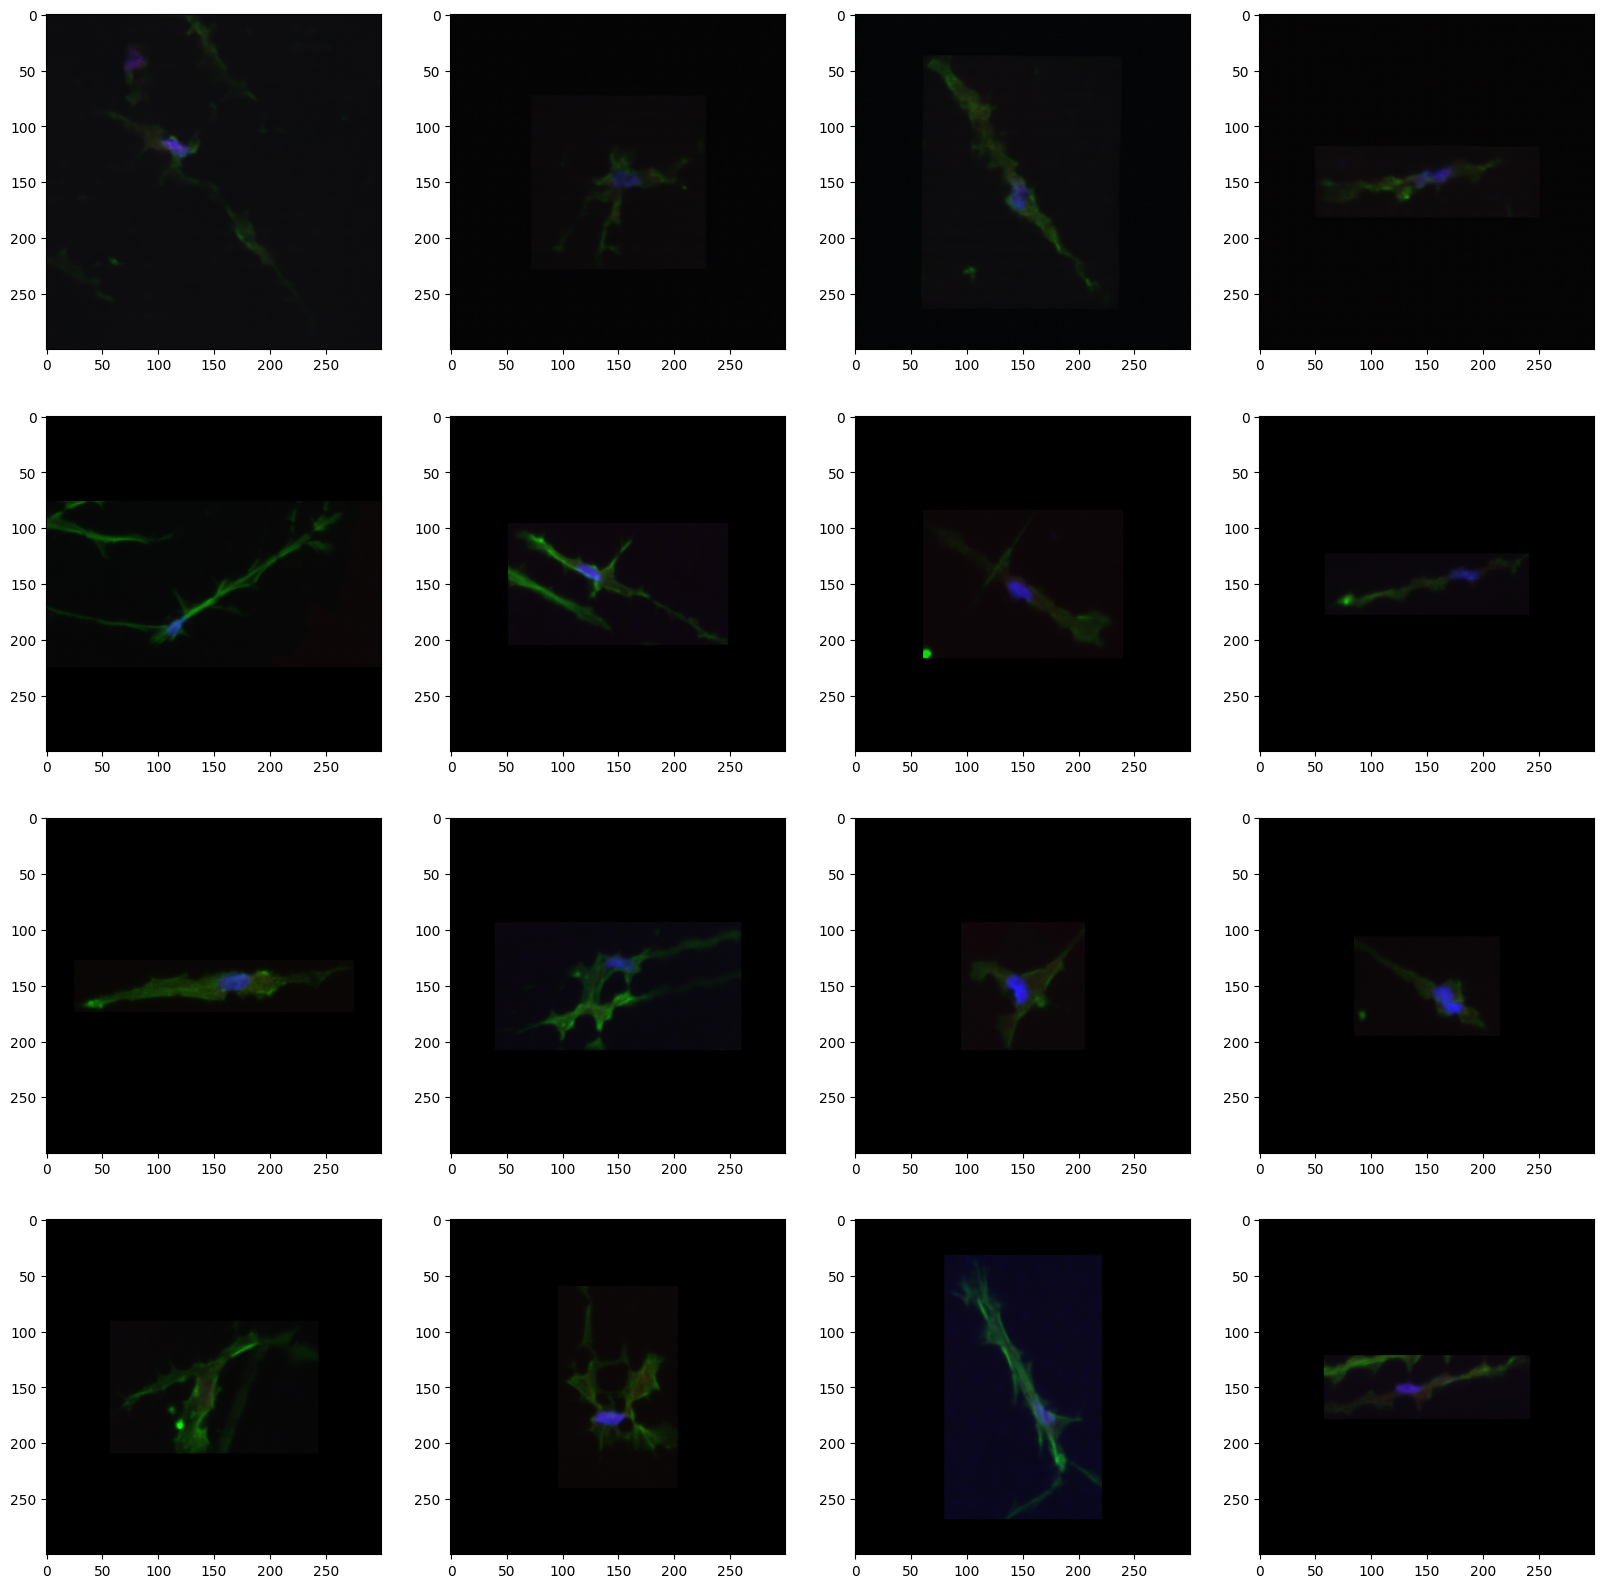

In [28]:
# plot the top_k most similar images:
fig, axs = plt.subplots(nrows=k+1, ncols=bs, figsize=(20,20))
for i in range(bs):
    axs[0, i].imshow(imgs[i, 1:].permute(1, 2, 0).cpu().detach().numpy()) # the first row is the generated images
    for j in range(k):
        axs[j+1, i].imshow(all_imgs[top_k_idx_feat_extr[i, j]].permute(1, 2, 0).cpu().detach().numpy())

plt.show()

In [ ]:
# randomly plot some generated images and images from the training set:

In [51]:
bs = 8
random_idx = np.random.choice(all_imgs.shape[0], bs)
some_bgs = all_bgs[random_idx][None, ...].to(device)
imgs_compare = generate_samples_topo(model, False, None, 0, 'test', some_bgs)

In [52]:
imgs_real = all_imgs[random_idx]

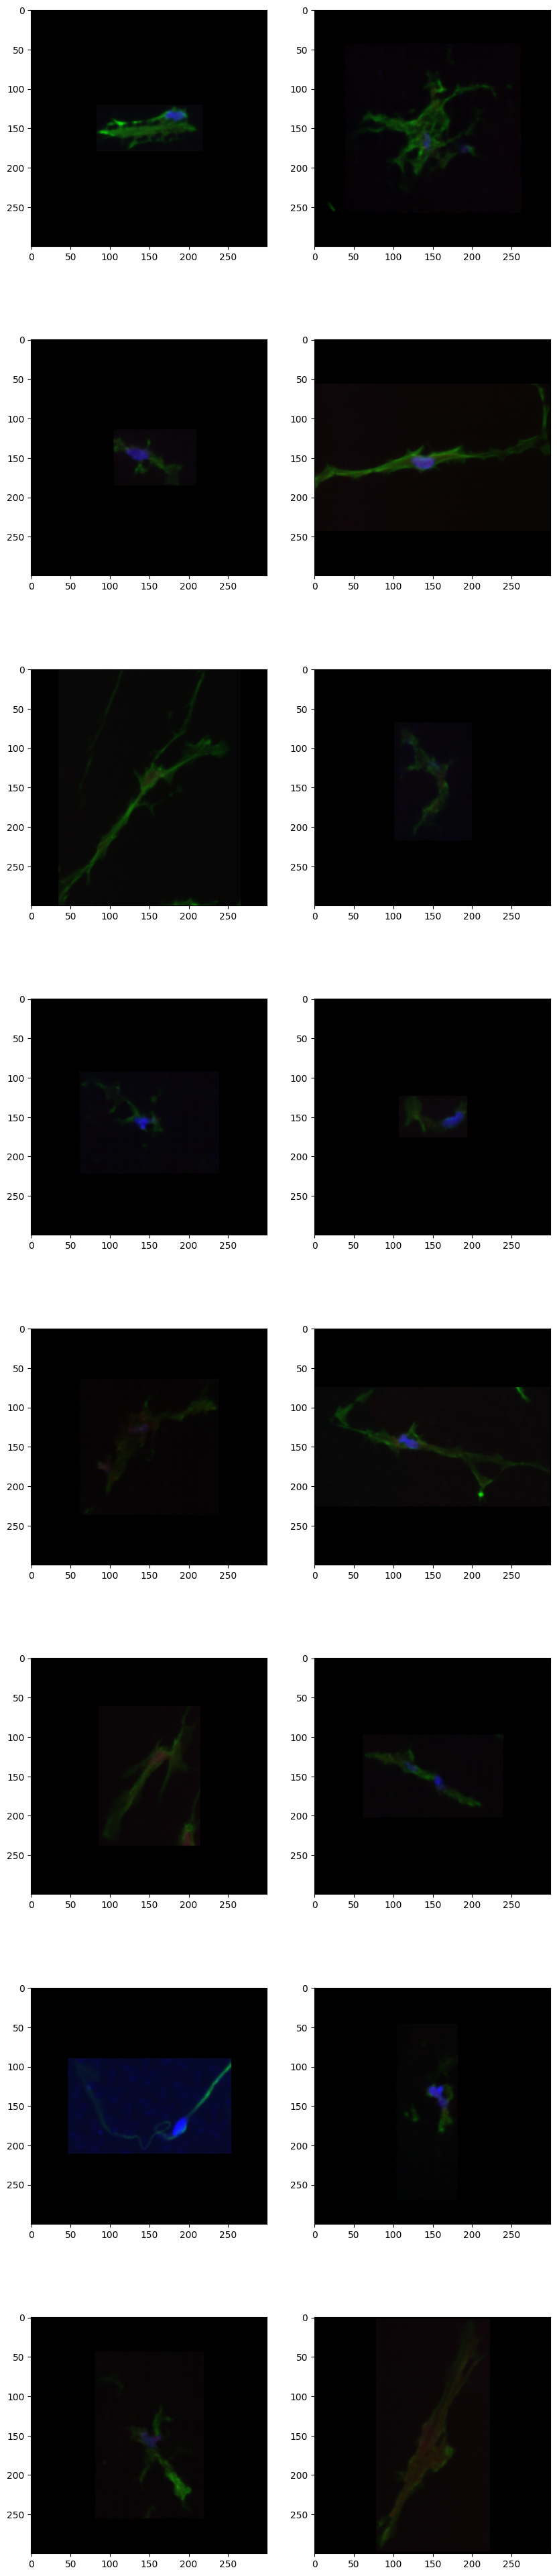

In [18]:
for l in real_locs:
    print(l)

0
0
0
0


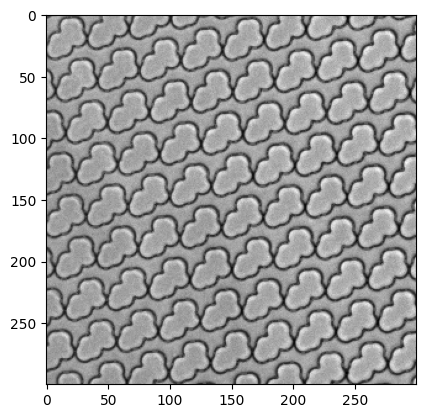

In [57]:
plt.figure()
plt.imshow(all_bgs[0].permute(1, 2, 0).cpu().detach().numpy(), cmap='grey')
plt.show()